## Long Short-Term Memory (LSTM) Networks

A Long Short-Term Memory (LSTM) network is an advanced type of Recurrent Neural Network (RNN) specifically designed to remember information for long periods.

Standard RNNs suffer from "short-term memory loss" (the Vanishing Gradient problem), meaning they forget earlier parts of a sequence as new data streams in. LSTMs solve this by introducing a Cell State—an internal conveyor belt that carries information straight down the sequence with only minor, highly controlled interactions.

The LSTM uses complex mathematical "valves" called Gates to explicitly decide what information gets added to the conveyor belt, what gets deleted, and what gets outputted.

#### The Three Gates (The Core Logic)

An LSTM maintains two states: the Hidden State ($h_t$) which acts as the short-term working memory, and the Cell State ($C_t$) which acts as the long-term memory.

At each time step $t$, the LSTM takes the current input ($x_t$) and the previous hidden state ($h_{t-1}$) and passes them through three distinct gates.

1. The Forget Gate: "What should we delete?"

The first step is deciding what long-term information is no longer relevant. It uses a Sigmoid function ($\sigma$) to output a number between 0 (completely forget) and 1 (completely keep).

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

2. The Input Gate: "What should we add?"

Next, the network decides what new information from the current step is worth saving to the long-term memory. This is a two-part process:

A. The Input Gate decides which values to update:


$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$

B. A Candidate Cell State creates a vector of new potential values that could be added:


$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

Updating the Long-Term Memory (Cell State):
Now, the network physically updates the conveyor belt. It multiplies the old state by the Forget Gate (deleting the old stuff), and adds the new information scaled by the Input Gate.

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

3. The Output Gate: "What should we output right now?"

Finally, the network decides what its prediction/output should be for the current step, based on a filtered version of the newly updated long-term memory.

A. Calculate the Output Gate:


$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

B. Calculate the new Hidden State (which also serves as the output for this step):


$$h_t = o_t \odot \tanh(C_t)$$

(Note: $\odot$ represents element-wise multiplication, and $W$ and $b$ are the learned weights and biases).

$[h_{t-1}, x_t]$ denotes the concatenation of the previous hidden state and the current input vector

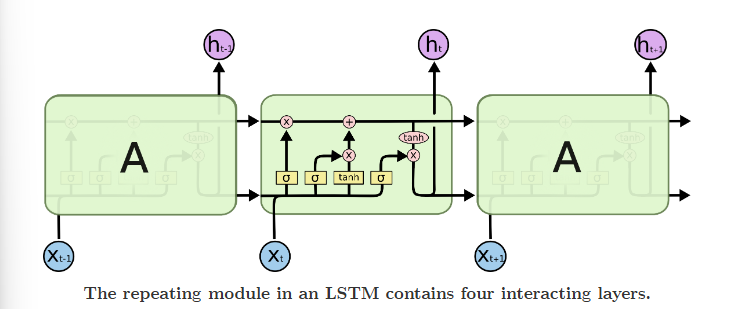
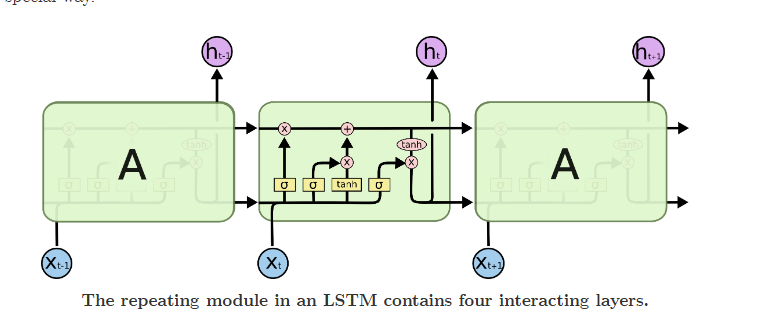

In [15]:
faqs = """About the Program
What is the course fee for  Data Science Mentorship Program (DSMP 2023)
The course follows a monthly subscription model where you have to make monthly payments of Rs 799/month.
What is the total duration of the course?
The total duration of the course is 7 months. So the total course fee becomes 799*7 = Rs 5600(approx.)
What is the syllabus of the mentorship program?
We will be covering the following modules:
Python Fundamentals
Python libraries for Data Science
Data Analysis
SQL for Data Science
Maths for Machine Learning
ML Algorithms
Practical ML
MLOPs
Case studies
You can check the detailed syllabus here - https://learnwith.campusx.in/courses/CampusX-Data-Science-Mentorship-Program-637339afe4b0615a1bbed390
Will Deep Learning and NLP be a part of this program?
No, NLP and Deep Learning both are not a part of this program’s curriculum.
What if I miss a live session? Will I get a recording of the session?
Yes all our sessions are recorded, so even if you miss a session you can go back and watch the recording.
Where can I find the class schedule?
Checkout this google sheet to see month by month time table of the course - https://docs.google.com/spreadsheets/d/16OoTax_A6ORAeCg4emgexhqqPv3noQPYKU7RJ6ArOzk/edit?usp=sharing.
What is the time duration of all the live sessions?
Roughly, all the sessions last 2 hours.
What is the language spoken by the instructor during the sessions?
Hinglish
How will I be informed about the upcoming class?
You will get a mail from our side before every paid session once you become a paid user.
Can I do this course if I am from a non-tech background?
Yes, absolutely.
I am late, can I join the program in the middle?
Absolutely, you can join the program anytime.
If I join/pay in the middle, will I be able to see all the past lectures?
Yes, once you make the payment you will be able to see all the past content in your dashboard.
Where do I have to submit the task?
You don’t have to submit the task. We will provide you with the solutions, you have to self evaluate the task yourself.
Will we do case studies in the program?
Yes.
Where can we contact you?
You can mail us at nitish.campusx@gmail.com
Payment/Registration related questions
Where do we have to make our payments? Your YouTube channel or website?
You have to make all your monthly payments on our website. Here is the link for our website - https://learnwith.campusx.in/
Can we pay the entire amount of Rs 5600 all at once?
Unfortunately no, the program follows a monthly subscription model.
What is the validity of monthly subscription? Suppose if I pay on 15th Jan, then do I have to pay again on 1st Feb or 15th Feb
15th Feb. The validity period is 30 days from the day you make the payment. So essentially you can join anytime you don’t have to wait for a month to end.
What if I don’t like the course after making the payment. What is the refund policy?
You get a 7 days refund period from the day you have made the payment.
I am living outside India and I am not able to make the payment on the website, what should I do?
You have to contact us by sending a mail at nitish.campusx@gmail.com
Post registration queries
Till when can I view the paid videos on the website?
This one is tricky, so read carefully. You can watch the videos till your subscription is valid. Suppose you have purchased subscription on 21st Jan, you will be able to watch all the past paid sessions in the period of 21st Jan to 20th Feb. But after 21st Feb you will have to purchase the subscription again.
But once the course is over and you have paid us Rs 5600(or 7 installments of Rs 799) you will be able to watch the paid sessions till Aug 2024.
Why lifetime validity is not provided?
Because of the low course fee.
Where can I reach out in case of a doubt after the session?
You will have to fill a google form provided in your dashboard and our team will contact you for a 1 on 1 doubt clearance session
If I join the program late, can I still ask past week doubts?
Yes, just select past week doubt in the doubt clearance google form.
I am living outside India and I am not able to make the payment on the website, what should I do?
You have to contact us by sending a mail at nitish.campusx@gmai.com
Certificate and Placement Assistance related queries
What is the criteria to get the certificate?
There are 2 criterias:
You have to pay the entire fee of Rs 5600
You have to attempt all the course assessments.
I am joining late. How can I pay payment of the earlier months?
You will get a link to pay fee of earlier months in your dashboard once you pay for the current month.
I have read that Placement assistance is a part of this program. What comes under Placement assistance?
This is to clarify that Placement assistance does not mean Placement guarantee. So we dont guarantee you any jobs or for that matter even interview calls. So if you are planning to join this course just for placements, I am afraid you will be disappointed. Here is what comes under placement assistance
Portfolio Building sessions
Soft skill sessions
Sessions with industry mentors
Discussion on Job hunting strategies
"""

In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

In [17]:
tokenizer = Tokenizer()

In [18]:
tokenizer.fit_on_texts([faqs])

In [19]:
len(tokenizer.word_index)

282

In [20]:
input_sequences = []
for sentence in faqs.split('\n'):
  tokenized_sentence = tokenizer.texts_to_sequences([sentence])[0]

  for i in range(1,len(tokenized_sentence)):
    input_sequences.append(tokenized_sentence[:i+1])

In [21]:
input_sequences

[[93, 1],
 [93, 1, 13],
 [11, 7],
 [11, 7, 1],
 [11, 7, 1, 12],
 [11, 7, 1, 12, 42],
 [11, 7, 1, 12, 42, 15],
 [11, 7, 1, 12, 42, 15, 43],
 [11, 7, 1, 12, 42, 15, 43, 53],
 [11, 7, 1, 12, 42, 15, 43, 53, 68],
 [11, 7, 1, 12, 42, 15, 43, 53, 68, 13],
 [11, 7, 1, 12, 42, 15, 43, 53, 68, 13, 147],
 [11, 7, 1, 12, 42, 15, 43, 53, 68, 13, 147, 148],
 [1, 12],
 [1, 12, 94],
 [1, 12, 94, 5],
 [1, 12, 94, 5, 44],
 [1, 12, 94, 5, 44, 29],
 [1, 12, 94, 5, 44, 29, 95],
 [1, 12, 94, 5, 44, 29, 95, 30],
 [1, 12, 94, 5, 44, 29, 95, 30, 2],
 [1, 12, 94, 5, 44, 29, 95, 30, 2, 8],
 [1, 12, 94, 5, 44, 29, 95, 30, 2, 8, 4],
 [1, 12, 94, 5, 44, 29, 95, 30, 2, 8, 4, 26],
 [1, 12, 94, 5, 44, 29, 95, 30, 2, 8, 4, 26, 44],
 [1, 12, 94, 5, 44, 29, 95, 30, 2, 8, 4, 26, 44, 69],
 [1, 12, 94, 5, 44, 29, 95, 30, 2, 8, 4, 26, 44, 69, 6],
 [1, 12, 94, 5, 44, 29, 95, 30, 2, 8, 4, 26, 44, 69, 6, 31],
 [1, 12, 94, 5, 44, 29, 95, 30, 2, 8, 4, 26, 44, 69, 6, 31, 70],
 [1, 12, 94, 5, 44, 29, 95, 30, 2, 8, 4, 26, 44, 69, 6

In [22]:
max_len = max([len(x) for x in input_sequences])

In [23]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_input_sequences = pad_sequences(input_sequences, maxlen = max_len, padding='pre')

In [24]:
X = padded_input_sequences[:,:-1]
y = padded_input_sequences[:,-1]

In [25]:
from tensorflow.keras.utils import to_categorical
y = to_categorical(y,num_classes=283)

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [34]:
model = Sequential([
    Embedding(283,100,input_length=56),
    # We add return_sequences=True so it outputs 3D data: (Batch, 56, 150)
    LSTM(150, return_sequences=True), 
    
    # The final LSTM can remain default (False) so it outputs 2D data: (Batch, 150)
    # which perfectly feeds into the Dense layer.
    LSTM(150), 
    Dense(283,activation='softmax')
])

In [35]:
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

In [36]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.fit(X,y,epochs=35)

Epoch 1/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.6466 - loss: 1.5939
Epoch 2/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.6790 - loss: 1.5126
Epoch 3/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.7045 - loss: 1.4451
Epoch 4/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.7254 - loss: 1.3811
Epoch 5/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.7358 - loss: 1.3274
Epoch 6/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7613 - loss: 1.2556
Epoch 7/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.7972 - loss: 1.1959
Epoch 8/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.7949 - loss: 1.1452
Epoch 9/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - accuracy: 0.8123 - loss: 1.1052
Epoch 10/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.8273 - loss: 1.0541
Epoch 11/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8273 - loss: 0.9987
Epoch 12/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accu

In [39]:
import time
import numpy as np 

text = "what is the fee"

for i in range(10):
  # tokenize
  token_text = tokenizer.texts_to_sequences([text])[0]
  # padding
  padded_token_text = pad_sequences([token_text], maxlen=56, padding='pre')
  # predict
  pos = np.argmax(model.predict(padded_token_text))

  for word,index in tokenizer.word_index.items():
    if index == pos:
      text = text + " " + word
      print(text)
      time.sleep(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
what is the fee spoken
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
what is the fee spoken by
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
what is the fee spoken by the
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
what is the fee spoken by the instructor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
what is the fee spoken by the instructor during
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
what is the fee spoken by the instructor during the
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
what is the fee spoken by the instructor during the sessions
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
what is the fee spoken by the instructor during the sessions sessions
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
what is the fee spoken by the instructor during the sessions sessions sessions
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
what is the fee spoken by the instructor during the sessions sessions sessions guarantee


Note: We can see that Last few line of process is incorrect due to the small amount of "epochs" is used for the train the model 

In [40]:
tokenizer.word_index

{'the': 1,
 'you': 2,
 'i': 3,
 'to': 4,
 'a': 5,
 'of': 6,
 'is': 7,
 'have': 8,
 'will': 9,
 'can': 10,
 'what': 11,
 'course': 12,
 'program': 13,
 'in': 14,
 'for': 15,
 'all': 16,
 'sessions': 17,
 'on': 18,
 'be': 19,
 'and': 20,
 'this': 21,
 'if': 22,
 'am': 23,
 'pay': 24,
 'payment': 25,
 'make': 26,
 'we': 27,
 'do': 28,
 'subscription': 29,
 'where': 30,
 'rs': 31,
 'so': 32,
 'campusx': 33,
 'session': 34,
 'our': 35,
 'paid': 36,
 'join': 37,
 'able': 38,
 'your': 39,
 'website': 40,
 'placement': 41,
 'fee': 42,
 'data': 43,
 'monthly': 44,
 'month': 45,
 'not': 46,
 'get': 47,
 'yes': 48,
 'once': 49,
 'past': 50,
 'feb': 51,
 'assistance': 52,
 'science': 53,
 '7': 54,
 '5600': 55,
 'are': 56,
 'watch': 57,
 'google': 58,
 'by': 59,
 'com': 60,
 'mail': 61,
 'from': 62,
 'contact': 63,
 'us': 64,
 'at': 65,
 'or': 66,
 'doubt': 67,
 'mentorship': 68,
 'payments': 69,
 '799': 70,
 'total': 71,
 'duration': 72,
 'months': 73,
 'learning': 74,
 'case': 75,
 'here': 76,
 '

#### list of all hyperparameters can pass to the LSTM layer

In [ ]:
lstm_layer = tf.keras.layers.LSTM(
    # --- ARCHITECTURAL ---
    units=150,               # The dimensionality of the output space (Memory size).
    activation='tanh',       # The activation function for the internal state.
    recurrent_activation='sigmoid', # Activation for the recurrent step (usually sigmoid).
    use_bias=True,           # Whether to use a bias vector for the gates.
    
    # --- SEQUENCING ---
    return_sequences=False,  # Set True if stacking another LSTM layer after this one.
    return_state=False,      # Set True if you need the final hidden and cell states outputted.
    go_backwards=False,      # Set True to process the input sequence in reverse.
    
    # --- REGULARIZATION ---
    dropout=0.0,             # Fraction of inputs to drop for the linear transformation.
    recurrent_dropout=0.0,   # Fraction of the recurrent state to drop (can slow down training).
    
    # --- INITIALIZATION ---
    kernel_initializer='glorot_uniform',    # Initializer for the input weights.
    recurrent_initializer='orthogonal',     # Initializer for the recurrent weights.
    bias_initializer='zeros',               # Initializer for the bias vector.
    
    # --- CONSTRAINTS ---
    kernel_constraint=None,  # Apply weight constraints (e.g., max_norm) here.
    recurrent_constraint=None,
    bias_constraint=None,
    
    # --- ADVANCED ---
    unit_forget_bias=True,   # If True, adds 1 to the bias of the forget gate at initialization.
    unroll=False,            # If True, network will be unrolled (faster for small sequences).
    time_major=False         # Expect input as (Batch, Time, Features) if False.
)

#### Which hyperparameters are most important?

1.  **`units`**: This is your most critical dial. More units = higher "IQ" and memory capacity, but also much higher risk of **overfitting** (where the model memorizes the data instead of learning patterns).
2.  **`dropout` & `recurrent_dropout`**: Use these when your model is overfitting. If your training accuracy is high but validation accuracy is low, increase your dropout (e.g., `dropout=0.2`).
3.  **`return_sequences`**: Remember to always set this to `True` for every LSTM layer except for the very last one before a Dense layer.
4.  **`activation`**: Almost always keep this as `'tanh'`. Changing it to `relu` can cause the gradients to explode in LSTMs unless you use very small learning rates.